[I 2025-03-06 18:54:47,855] A new study created in memory with name: no-name-369abe09-b688-458d-9c03-caf475ceba37
[I 2025-03-06 18:54:48,938] Trial 0 finished with value: 0.8903508771929824 and parameters: {'n_estimators': 127, 'max_depth': 17, 'min_samples_split': 17, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.8903508771929824.
[I 2025-03-06 18:54:49,162] Trial 1 finished with value: 0.8969298245614035 and parameters: {'n_estimators': 52, 'max_depth': 19, 'min_samples_split': 13, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.8969298245614035.
[I 2025-03-06 18:54:49,551] Trial 2 finished with value: 0.8662280701754386 and parameters: {'n_estimators': 88, 'max_depth': 20, 'min_samples_split': 14, 'min_samples_leaf': 10}. Best is trial 1 with value: 0.8969298245614035.
[I 2025-03-06 18:54:50,362] Trial 3 finished with value: 0.8728070175438597 and parameters: {'n_estimators': 199, 'max_depth': 10, 'min_samples_split': 17, 'min_samples_leaf': 1}. Best is trial 1 with va

Best Hyperparameters: {'n_estimators': 72, 'max_depth': 11, 'min_samples_split': 3, 'min_samples_leaf': 1}


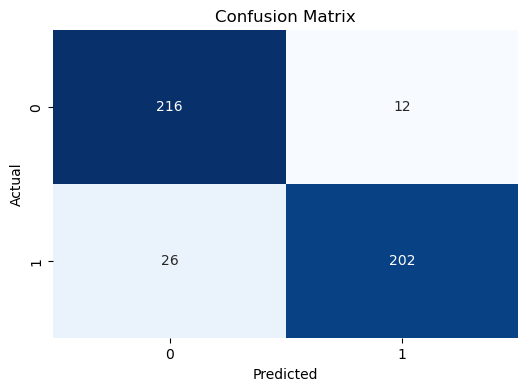

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.95      0.92       228
           1       0.94      0.89      0.91       228

    accuracy                           0.92       456
   macro avg       0.92      0.92      0.92       456
weighted avg       0.92      0.92      0.92       456

Accuracy: 0.9166666666666666
                        Importance
cumulative_rainfall_1d    0.068789
cumulative_rainfall_3d    0.137132
cumulative_rainfall_5d    0.133175
rainfall_intensity_1d     0.062057
rainfall_intensity_3d     0.068121
rainfall_intensity_5d     0.092141
soil_moisture             0.255084
slope                     0.144779
soil_type                 0.038722
Landslide Prediction: No


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import optuna  # For Bayesian optimization
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = pd.read_csv('landslide2(1).csv')

# Split the dataset into features (X) and target (y)
X = df.drop(columns=["target_classification"])
y = df["target_classification"]

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply Scaling (Optional but recommended)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the objective function for Bayesian optimization
def objective(trial):
    # Suggest values for hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 50, 200)  
    max_depth = trial.suggest_int('max_depth', 5, 20)          
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)  
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)    

    # Create a Random Forest model with suggested hyperparameters
    rf_model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )
    
    # Train the model on the training set
    rf_model.fit(X_train_scaled, y_train)
    
    # Evaluate the model on the validation set
    y_pred = rf_model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    
    return accuracy  

# Run Bayesian optimization
study = optuna.create_study(direction='maximize')  
study.optimize(objective, n_trials=100)  

# Best hyperparameters from Bayesian optimization
best_params = study.best_params
print("Best Hyperparameters:", best_params)

# Train the final Random Forest model using the best parameters
rf_model = RandomForestClassifier(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)

# Predict the target for the test set
y_pred = rf_model.predict(X_test_scaled)

# Performance metrics
accuracy = accuracy_score(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Print classification report and accuracy
print("Classification Report:\n", class_report)
print("Accuracy:", accuracy)

# Feature Importance
features = pd.DataFrame(rf_model.feature_importances_, index=X.columns, columns=["Importance"])
print(features.head(30))

# Example of a new data point 
new_data = np.array([[0.3, 1.8, 2.5, 0.1, 0.1, 0.1, 1.6, 1, 2]])  # Same order as training features

# Convert new_data to a DataFrame with the same column names as X
new_data_df = pd.DataFrame(new_data, columns=X.columns)

# Apply the same scaling transformation that was used on X_train
new_data_scaled = scaler.transform(new_data_df)

# Predict landslide occurrence
prediction = rf_model.predict(new_data_scaled)
print("Landslide Prediction:", "Yes" if prediction[0] == 1 else "No")

[I 2025-03-07 12:28:58,590] A new study created in memory with name: no-name-03671729-ac53-4990-9d2f-f1ba40f9c491
[I 2025-03-07 12:28:58,981] Trial 0 finished with value: 0.881578947368421 and parameters: {'n_estimators': 78, 'max_depth': 8, 'min_samples_split': 9, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.881578947368421.
[I 2025-03-07 12:28:59,867] Trial 1 finished with value: 0.8881578947368421 and parameters: {'n_estimators': 183, 'max_depth': 19, 'min_samples_split': 9, 'min_samples_leaf': 5}. Best is trial 1 with value: 0.8881578947368421.
[I 2025-03-07 12:29:00,551] Trial 2 finished with value: 0.868421052631579 and parameters: {'n_estimators': 157, 'max_depth': 11, 'min_samples_split': 17, 'min_samples_leaf': 2}. Best is trial 1 with value: 0.8881578947368421.
[I 2025-03-07 12:29:00,803] Trial 3 finished with value: 0.868421052631579 and parameters: {'n_estimators': 65, 'max_depth': 18, 'min_samples_split': 12, 'min_samples_leaf': 10}. Best is trial 1 with value: 0.

Best Hyperparameters: {'n_estimators': 183, 'max_depth': 19, 'min_samples_split': 9, 'min_samples_leaf': 5}


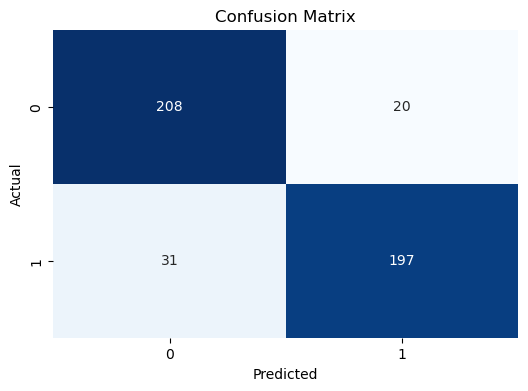

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.91      0.89       228
           1       0.91      0.86      0.89       228

    accuracy                           0.89       456
   macro avg       0.89      0.89      0.89       456
weighted avg       0.89      0.89      0.89       456

Accuracy: 0.8881578947368421
                        Importance
soil_moisture             0.279359
slope                     0.163006
cumulative_rainfall_5d    0.131080
cumulative_rainfall_3d    0.127553
rainfall_intensity_5d     0.079145
rainfall_intensity_3d     0.066846
cumulative_rainfall_1d    0.063982
rainfall_intensity_1d     0.052007
soil_type                 0.037021
Landslide Prediction: No
SHAP values shape: (9, 2)
Feature matrix shape: (456, 9)
Difference in columns: -7


ValueError: SHAP values shape has fewer columns than expected.

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import optuna  # For Bayesian optimization
import shap    # For SHAP visualizations
from sklearn.inspection import PartialDependenceDisplay

# Load the dataset
df = pd.read_csv('landslide2(1).csv')

# Split the dataset into features (X) and target (y)
X = df.drop(columns=["target_classification"])
y = df["target_classification"]

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply Scaling (Optional but recommended)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the objective function for Bayesian optimization
def objective(trial):
    # Suggest values for hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 50, 200)  
    max_depth = trial.suggest_int('max_depth', 5, 20)          
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)  
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)    

    # Create a Random Forest model with suggested hyperparameters
    rf_model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )
    
    # Train the model on the training set
    rf_model.fit(X_train_scaled, y_train)
    
    # Evaluate the model on the validation set
    y_pred = rf_model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    
    return accuracy  

# Run Bayesian optimization
study = optuna.create_study(direction='maximize')  
study.optimize(objective, n_trials=10)  

# Best hyperparameters from Bayesian optimization
best_params = study.best_params
print("Best Hyperparameters:", best_params)

# Train the final Random Forest model using the best parameters
rf_model = RandomForestClassifier(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)

# Predict the target for the test set
y_pred = rf_model.predict(X_test_scaled)

# Performance metrics
accuracy = accuracy_score(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Print classification report and accuracy
print("Classification Report:\n", class_report)
print("Accuracy:", accuracy)

# Feature Importance from the Random Forest
features = pd.DataFrame(rf_model.feature_importances_, index=X.columns, columns=["Importance"])
print(features.sort_values("Importance", ascending=False).head(30))

# Example of a new data point (make sure the order matches your features)
new_data = np.array([[0.3, 1.8, 2.5, 0.1, 0.1, 0.1, 1.6, 1, 2]])
new_data_df = pd.DataFrame(new_data, columns=X.columns)
new_data_scaled = scaler.transform(new_data_df)
prediction = rf_model.predict(new_data_scaled)
print("Landslide Prediction:", "Yes" if prediction[0] == 1 else "No")

# ================================
# Visualization: SHAP Summary and Dependence Plots
# ================================

# Create a SHAP TreeExplainer for the Random Forest model
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_scaled)

# Convert X_test_scaled to a DataFrame for plotting (to retain feature names)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# Determine the difference in the number of columns
diff = shap_values[1].shape[1] - X_test_scaled_df.shape[1]
print("SHAP values shape:", shap_values[1].shape)
print("Feature matrix shape:", X_test_scaled_df.shape)
print("Difference in columns:", diff)

# Adjust SHAP values based on the difference
if diff > 0:
    # If there are extra columns, remove the last 'diff' columns
    shap_values_adjusted = shap_values[1][:, : -diff]
elif diff == 0:
    shap_values_adjusted = shap_values[1]
else:
    raise ValueError("SHAP values shape has fewer columns than expected.")

# Now create the SHAP Summary Plot for the positive class (landslide = 1)
shap.summary_plot(shap_values_adjusted, X_test_scaled_df, feature_names=X.columns)

# And create a SHAP Dependence Plot for a selected feature (e.g., "soil_moisture")
shap.dependence_plot("soil_moisture", shap_values_adjusted, X_test_scaled_df, feature_names=X.columns)


# ================================
# Visualization: Partial Dependence Plots (PDPs)
# ================================

# For PDPs, we use the scaled test set but convert it back to a DataFrame with proper column names
PartialDependenceDisplay.from_estimator(
    rf_model,
    X_test_scaled_df,
    features=X.columns.tolist(),  # Plot PDPs for all features; you can choose a subset if preferred
    grid_resolution=50
)
plt.show()
